In [22]:
# ==========================================
# STEP 1: IMPORT LIBRARY & INITIALIZATION
# ==========================================
import pandas as pd
import numpy as np
import joblib
import warnings

from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore', category=UserWarning)
print("Step 1: Semua library berhasil dimuat.")

Step 1: Semua library berhasil dimuat.


In [23]:
# ==========================================
# STEP 2: LOAD DATA & FEATURE ENGINEERING
# ==========================================
# 1. Memuat kolom esensial dari dataset
columns = ['datetime', 'latitude', 'longitude', 'magnitude', 'depth']
df = pd.read_csv('katalog_gempa.tsv', sep='\t', usecols=columns)
df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
df = df.dropna()

# 2. Rekayasa Fitur Spasial (Membuat Grid Koordinat)
df['lat_grid'] = df['latitude'].round(1)
df['lon_grid'] = df['longitude'].round(1)

# 3. Rekayasa Fitur Temporal (Menghitung selisih waktu antar gempa)
df = df.sort_values(by=['lat_grid', 'lon_grid', 'datetime'])
df['time_diff_hours'] = df.groupby(['lat_grid', 'lon_grid'])['datetime'].diff().dt.total_seconds() / 3600
df['time_diff_hours'] = df['time_diff_hours'].fillna(9999) # Gempa pertama di grid tersebut

print(f"Step 2: Data berhasil dibersihkan. Total baris: {len(df)}")

Step 2: Data berhasil dibersihkan. Total baris: 131134


In [24]:
# ==========================================
# STEP 3: RULE-BASED LABELING UNTUK TARGET KLASIFIKASI (EKSPLISIT)
# ==========================================
df_clf = df.copy()

def label_risk(row):
    # 1. Definisi Aturan Kelas TINGGI
    rule_tinggi = (
        (row['magnitude'] >= 6.5) or
        (row['magnitude'] >= 6.0 and row['depth'] < 50) or
        (row['magnitude'] >= 4.5 and row['time_diff_hours'] <= 24)
    )

    # 2. Definisi Aturan Kelas SEDANG
    # (Magnitudo >= 5.0 DAN tidak memenuhi aturan Tinggi)
    rule_sedang = (row['magnitude'] >= 5.0) and not rule_tinggi

    # 3. Eksekusi Pelabelan
    if rule_tinggi:
        return 'Tinggi'
    elif rule_sedang:
        return 'Sedang'
    else:
        # Aturan Kelas RENDAH (Selain Tinggi dan Sedang)
        return 'Rendah'

# Menerapkan label ke dataset
df_clf['risk_category'] = df_clf.apply(label_risk, axis=1)

# Mengubah label teks menjadi angka (0, 1, 2)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_clf['target_class'] = encoder.fit_transform(df_clf['risk_category'])

print("Step 3: Pelabelan target risiko (Eksplisit) berhasil dilakukan.")

Step 3: Pelabelan target risiko (Eksplisit) berhasil dilakukan.


In [25]:
# ==========================================
# STEP 4 & 5: DATA SPLIT & PIPELINE KLASIFIKASI (ROBUST & KOMPREHENSIF)
# ==========================================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# 1. Mengurutkan ulang secara kronologis (Mencegah Temporal Leakage)
df_clf = df_clf.sort_values(by='datetime')

X_c = df_clf[['magnitude', 'depth', 'latitude', 'longitude', 'time_diff_hours']]
y_c = df_clf['target_class']

# 2. Membagi data (80% Latih, 20% Uji) TANPA Shuffle
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, shuffle=False)

# 3. Menentukan k_neighbors dinamis untuk SMOTE (Mencegah Error Minoritas Ekstrem)
# Jika jumlah gempa Tinggi/Sedang sangat sedikit, k_neighbors akan otomatis mengecil
min_class_count = y_train_c.value_counts().min()
dynamic_k = min(5, min_class_count - 1) if min_class_count > 1 else 1

# 4. CORE PIPELINE
pipeline_clf = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),            # 1. Amankan dari nilai kosong (NaN)
    ('scaler', RobustScaler()),                               # 2. Amankan dari outlier (ex: 9999 jam)
    ('smote', SMOTE(k_neighbors=dynamic_k, random_state=42)), # 3. Penyeimbang kelas minoritas
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)) # 4. Latih Model
])

# 5. Melatih Pipeline
print(f"Melatih Pipeline Klasifikasi (SMOTE k_neighbors = {dynamic_k})...")
pipeline_clf.fit(X_train_c, y_train_c)

# 6. Evaluasi ke data uji (Pipeline otomatis mem-bypass SMOTE di sini)
y_pred_c = pipeline_clf.predict(X_test_c)

# 7. Menampilkan Hasil Evaluasi Secara Komprehensif
print(f"\n--- EVALUASI METRIK PIPELINE KLASIFIKASI ---")
print(f"Accuracy          : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Balanced Accuracy : {balanced_accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Macro F1-Score    : {f1_score(y_test_c, y_pred_c, average='macro'):.4f}")
print(f"Weighted F1-Score : {f1_score(y_test_c, y_pred_c, average='weighted'):.4f}\n")

nama_kelas = encoder.inverse_transform([0, 1, 2])
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=nama_kelas))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_c, y_pred_c)
df_cm = pd.DataFrame(cm, index=[f"Aktual {k}" for k in nama_kelas], columns=[f"Prediksi {k}" for k in nama_kelas])
print(df_cm)

Melatih Pipeline Klasifikasi (SMOTE k_neighbors = 5)...

--- EVALUASI METRIK PIPELINE KLASIFIKASI ---
Accuracy          : 0.9997
Balanced Accuracy : 0.9873
Macro F1-Score    : 0.9885
Weighted F1-Score : 0.9997

Classification Report:
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00     25795
      Sedang       1.00      0.99      0.99       286
      Tinggi       0.97      0.97      0.97       146

    accuracy                           1.00     26227
   macro avg       0.99      0.99      0.99     26227
weighted avg       1.00      1.00      1.00     26227

Confusion Matrix:
               Prediksi Rendah  Prediksi Sedang  Prediksi Tinggi
Aktual Rendah            25793                1                1
Aktual Sedang                0              283                3
Aktual Tinggi                4                0              142


In [26]:
# ==========================================
# STEP 6: EKSTRAKSI TARGET ESTIMASI KEWASPADAAN
# ==========================================
df_reg = df.copy()
event_limit = 72 # Batas 72 jam untuk mendefinisikan siklus gempa baru

# Mendeteksi siklus kejadian (Event)
df_reg['is_new_event'] = (df_reg['time_diff_hours'] > event_limit)
df_reg['event_id'] = df_reg.groupby(['lat_grid', 'lon_grid'])['is_new_event'].cumsum()

# Menghitung durasi historis dari gempa utama hingga gempa susulan terakhir mereda
event_stats = df_reg.groupby(['lat_grid', 'lon_grid', 'event_id'])['datetime'].agg(['min', 'max']).reset_index()

# Mengganti nama kolom agar sesuai dengan konsep kewaspadaan mitigasi
event_stats['durasi_kewaspadaan_jam'] = (event_stats['max'] - event_stats['min']).dt.total_seconds() / 3600

# Memasukkan target ke data Gempa Utama (Magnitudo >= 4.5)
df_main = df_reg[df_reg['is_new_event'] == True].copy()
df_main = pd.merge(df_main, event_stats[['lat_grid', 'lon_grid', 'event_id', 'durasi_kewaspadaan_jam']],
                   on=['lat_grid', 'lon_grid', 'event_id'], how='left')

df_reg_final = df_main[df_main['magnitude'] >= 4.5].copy()

print("Step 6: Data historis durasi kewaspadaan berhasil diekstrak.")

Step 6: Data historis durasi kewaspadaan berhasil diekstrak.


In [27]:
# ==========================================
# STEP 7: TRAINING & EVALUASI ESTIMASI KEWASPADAAN (KOMPREHENSIF)
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mengurutkan ulang secara kronologis
df_reg_final = df_reg_final.sort_values(by='datetime')

X_r = df_reg_final[['magnitude', 'depth', 'latitude', 'longitude']]
y_r = df_reg_final['durasi_kewaspadaan_jam']

# 2. Split Data (Tanpa Shuffle untuk Time-Series)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, shuffle=False)

# 3. MEMBANGUN PIPELINE REGRESI (Fault-Tolerant)
pipeline_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Mencegah error jika data BMKG ada yang kosong (NaN)
    ('scaler', RobustScaler()),                    # Mencegah bias dari outlier koordinat/kedalaman
    ('regressor', XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42))
])

# 4. Latih Pipeline
print("Melatih Pipeline Estimasi Kewaspadaan (Imputer -> RobustScaler -> XGBoost)...")
pipeline_reg.fit(X_train_r, y_train_r)

# 5. Prediksi Data Uji (Nilai waktu tidak boleh minus, kita batasi minimal 0)
y_pred_r = np.maximum(0, pipeline_reg.predict(X_test_r))

# 6. Menghitung Metrik Evaluasi Komprehensif
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

# 7. Menampilkan Hasil Evaluasi
print(f"\n--- EVALUASI PIPELINE ESTIMASI KEWASPADAAN ---")
print(f"MAE (Mean Absolute Error) : {mae:.2f} Jam")
print(f"RMSE (Root Mean Sq Error) : {rmse:.2f} Jam")
print(f"R-Squared (R2 Score)      : {r2:.4f}")

Melatih Pipeline Estimasi Kewaspadaan (Imputer -> RobustScaler -> XGBoost)...

--- EVALUASI PIPELINE ESTIMASI KEWASPADAAN ---
MAE (Mean Absolute Error) : 5.41 Jam
RMSE (Root Mean Sq Error) : 26.51 Jam
R-Squared (R2 Score)      : -0.0177


In [28]:
# ==========================================
# STEP 8: EXPORT MODEL ARTIFACTS
# ==========================================
import joblib

# Menyimpan pipeline utuh (sudah membungkus Imputer, Scaler, SMOTE, & XGBoost)
joblib.dump(pipeline_clf, 'pipeline_xgboost_gempa.pkl')

# Menyimpan kamus penerjemah label (Tinggi/Sedang/Rendah)
joblib.dump(encoder, 'label_encoder.pkl')

# Menyimpan pipeline regresi cooldown (Imputer, Scaler, XGBoost)
joblib.dump(pipeline_reg, 'pipeline_xgboost_cooldown.pkl')

print("Step 8: Seluruh arsitektur pipeline berhasil disimpan menjadi .pkl!")
print("Siap di-deploy ke server Backend!")

Step 8: Seluruh arsitektur pipeline berhasil disimpan menjadi .pkl!
Siap di-deploy ke server Backend!


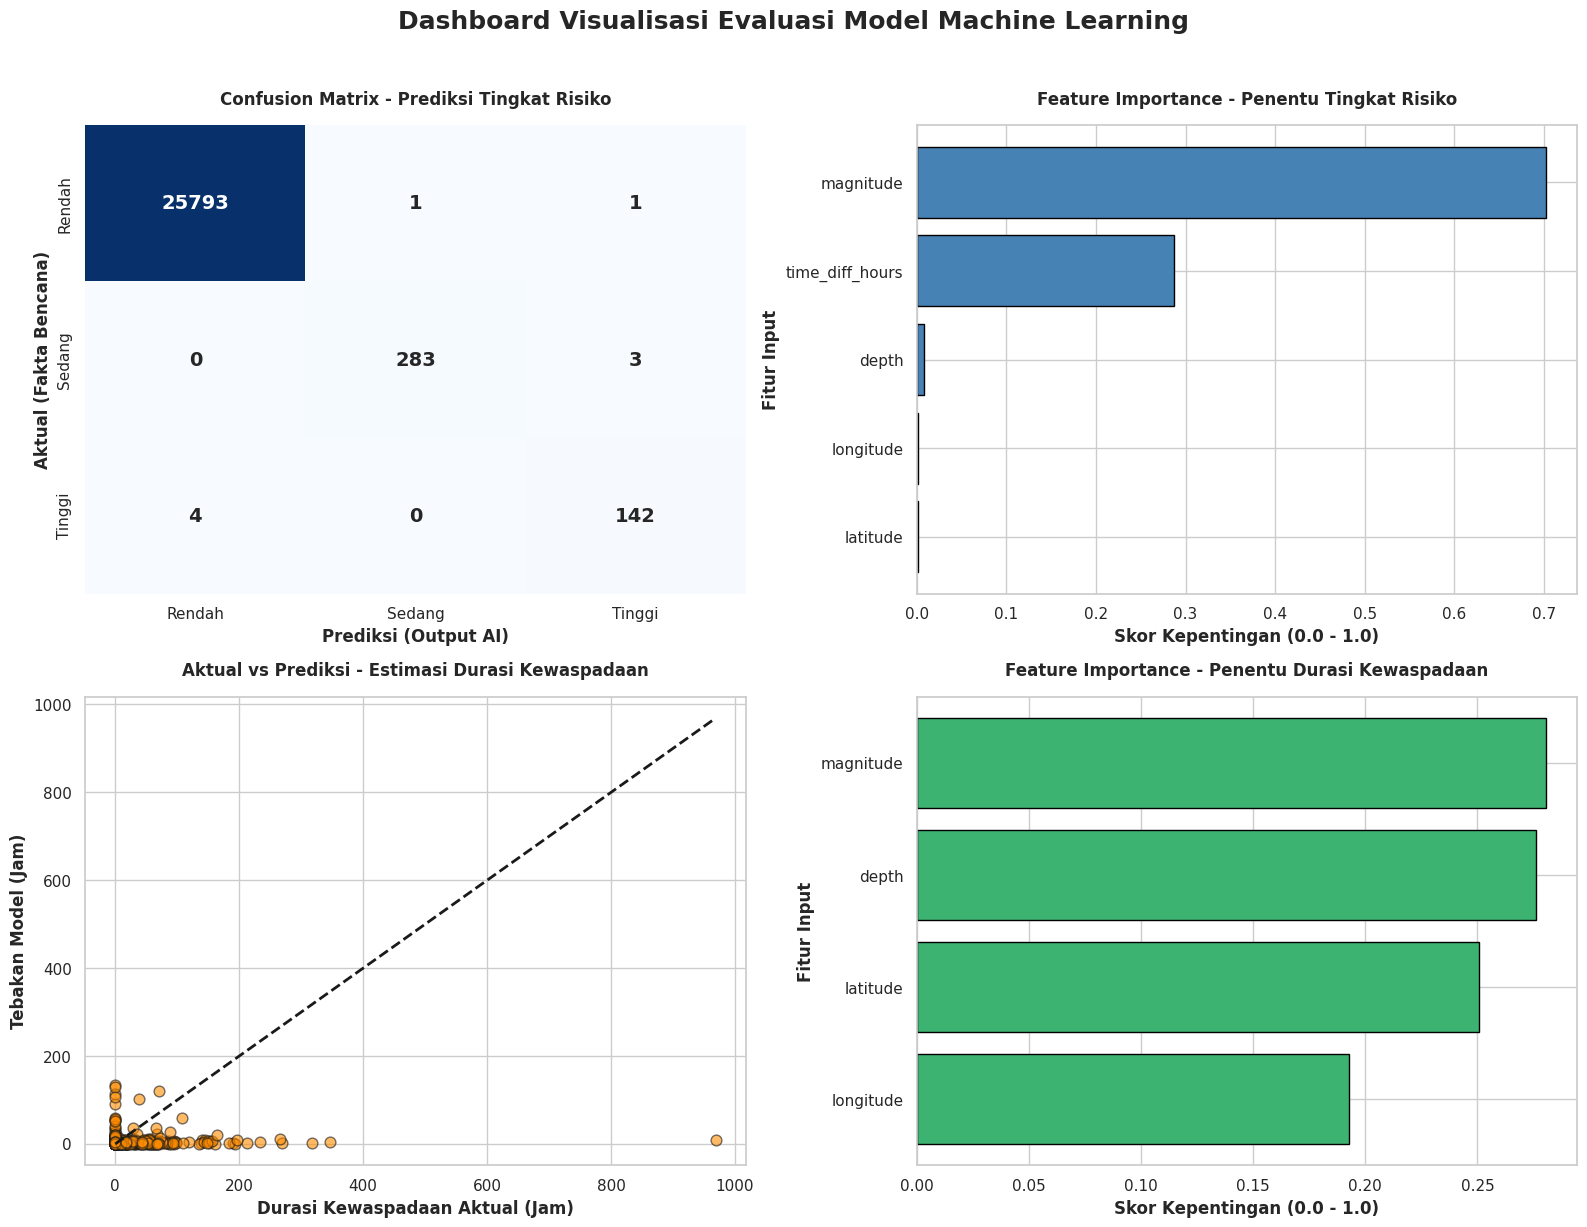

In [29]:
# ==========================================
# STEP 9: VISUALISASI EVALUASI MODEL
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visual agar terlihat profesional dan siap masuk skripsi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Membuat figure grid 2x2 untuk menampung 4 grafik sekaligus
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Visualisasi Evaluasi Model Machine Learning', fontsize=18, fontweight='bold', y=1.02)

# ---------------------------------------------------------
# 1. VISUALISASI KLASIFIKASI: CONFUSION MATRIX (HEATMAP)
# ---------------------------------------------------------
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nama_kelas, yticklabels=nama_kelas, ax=axes[0, 0],
            annot_kws={"size": 14, "weight": "bold"})
axes[0, 0].set_title('Confusion Matrix - Prediksi Tingkat Risiko', pad=15, fontweight='bold')
axes[0, 0].set_ylabel('Aktual (Fakta Bencana)', fontweight='bold')
axes[0, 0].set_xlabel('Prediksi (Output AI)', fontweight='bold')

# ---------------------------------------------------------
# 2. VISUALISASI KLASIFIKASI: FEATURE IMPORTANCE
# ---------------------------------------------------------
# Mengekstrak bobot fitur dari dalam pipeline XGBoost
importances_clf = pipeline_clf.named_steps['classifier'].feature_importances_
sorted_idx_clf = importances_clf.argsort()

axes[0, 1].barh(X_c.columns[sorted_idx_clf], importances_clf[sorted_idx_clf], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Feature Importance - Penentu Tingkat Risiko', pad=15, fontweight='bold')
axes[0, 1].set_xlabel('Skor Kepentingan (0.0 - 1.0)', fontweight='bold')
axes[0, 1].set_ylabel('Fitur Input', fontweight='bold')

# ---------------------------------------------------------
# 3. VISUALISASI REGRESI: ACTUAL VS PREDICTED (SCATTER PLOT)
# ---------------------------------------------------------
axes[1, 0].scatter(y_test_r, y_pred_r, alpha=0.6, color='darkorange', edgecolors='k', s=60)
# Membuat garis putus-putus diagonal sebagai indikator "Tebakan Sempurna"
axes[1, 0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'k--', lw=2)
axes[1, 0].set_title('Aktual vs Prediksi - Estimasi Durasi Kewaspadaan', pad=15, fontweight='bold')
axes[1, 0].set_xlabel('Durasi Kewaspadaan Aktual (Jam)', fontweight='bold')
axes[1, 0].set_ylabel('Tebakan Model (Jam)', fontweight='bold')

# ---------------------------------------------------------
# 4. VISUALISASI REGRESI: FEATURE IMPORTANCE
# ---------------------------------------------------------
# Mengekstrak bobot fitur regresi
importances_reg = pipeline_reg.named_steps['regressor'].feature_importances_
sorted_idx_reg = importances_reg.argsort()

axes[1, 1].barh(X_r.columns[sorted_idx_reg], importances_reg[sorted_idx_reg], color='mediumseagreen', edgecolor='black')
axes[1, 1].set_title('Feature Importance - Penentu Durasi Kewaspadaan', pad=15, fontweight='bold')
axes[1, 1].set_xlabel('Skor Kepentingan (0.0 - 1.0)', fontweight='bold')
axes[1, 1].set_ylabel('Fitur Input', fontweight='bold')

# Merapikan jarak antar grafik agar tidak bertumpuk
plt.tight_layout()
plt.show()